# 03 - Modele ML de Classification

**Objectif:** Predire la satisfaction client (Satisfied vs Neutral/Dissatisfied)

**Architecture:**
- Donnees CSV -> `airline_passenger_satisfaction.csv`
- Modeles: RandomForest, XGBoost, LogisticRegression
- Metriques: Accuracy, Precision, Recall, F1, ROC-AUC

## 1. Imports et Configuration

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import logging
import joblib
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

PROJECT_ROOT = Path("/home/esprit/airlLines_Project")
CSV_DIR = PROJECT_ROOT / "dataSetAirlines"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

log_file = RESULTS_DIR / 'training.log'
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info("=== SESSION START ===")
logger.info(f"Dataset: airline_passenger_satisfaction.csv")
logger.info(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("Configuration chargee")
print(f"CSV: {CSV_DIR}")
print(f"Results: {RESULTS_DIR}")
print(f"Log file: {log_file}")

2026-05-25 01:23:35,544 - INFO - === SESSION START ===
2026-05-25 01:23:35,556 - INFO - Dataset: airline_passenger_satisfaction.csv
2026-05-25 01:23:35,558 - INFO - Date: 2026-05-25 01:23:35


Configuration chargee
CSV: /home/esprit/airlLines_Project/dataSetAirlines
Results: /home/esprit/airlLines_Project/results
Log file: /home/esprit/airlLines_Project/results/training.log


## 2. Chargement et Preparation des Donnees

In [170]:
df = pd.read_csv(CSV_DIR / "airline_passenger_satisfaction.csv")

print(f"Dataset: {df.shape}")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nValeurs manquantes:\n{df.isnull().sum()}")
print(f"\nDistribution de Satisfaction:")
print(df['Satisfaction'].value_counts())

Dataset: (129880, 24)

Colonnes: ['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Satisfaction']

Valeurs manquantes:
ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                  

## 3. Pretraitement Intelligent

In [171]:
print("=== ANALYSE DES VALEURS MANQUANTES ===")
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
print(f"Valeurs manquantes:\n{missing_counts}")
print(f"\nTotal lignes avant traitement: {len(df)}")

if 'Arrival Delay' in missing_cols.index:
    print("\n--- ANALYSE DU PATTERN DE MISSING ---")
    
    missing_df = df[df['Arrival Delay'].isna()]
    print(f"Nombre de lignes: {len(missing_df)}")
    print(f"Departure Delay des lignes manquantes:")
    print(missing_df['Departure Delay'].value_counts().head(10))
    
    valid_df = df.dropna(subset=['Arrival Delay'])
    corr_delays = valid_df['Departure Delay'].corr(valid_df['Arrival Delay'], method='spearman')
    print(f"\nCorrélation Departure/Arrival Delay: {corr_delays:.4f}")
    
    df_clean = df.copy()
    
    if (missing_df['Departure Delay'] == 0).all():
        df_clean['Arrival Delay'] = df_clean['Arrival Delay'].fillna(0)
        print("\n✅ IMPUTATION: Arrival Delay = 0 (vols à l'heure)")
    elif corr_delays > 0.95:
        df_clean['Arrival Delay'] = df_clean['Arrival Delay'].fillna(df_clean['Departure Delay'])
        print("\n✅ IMPUTATION: Arrival Delay = Departure Delay")
    else:
        median_delay = df_clean['Arrival Delay'].median()
        df_clean['Arrival Delay'] = df_clean['Arrival Delay'].fillna(median_delay)
        print(f"\n✅ IMPUTATION: Médiane = {median_delay:.2f}")
else:
    df_clean = df.copy()

df_clean = df_clean.drop('ID', axis=1, errors='ignore')
print(f"\nDataset final: {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")

=== ANALYSE DES VALEURS MANQUANTES ===
Valeurs manquantes:
ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Servic

## 4. Encodage de la Cible

In [172]:
le = LabelEncoder()
df_clean['target'] = le.fit_transform(df_clean['Satisfaction'])
print(f"Classes: {le.classes_}")
print(f"Encodage: 0 = '{le.classes_[0]}', 1 = '{le.classes_[1]}'")

feature_cols = [col for col in df_clean.columns if col not in ['Satisfaction', 'target']]
cat_cols = df_clean[feature_cols].select_dtypes(include=['object']).columns.tolist()
num_cols = [col for col in feature_cols if col not in cat_cols]

print(f"\n=== FEATURES ({len(feature_cols)}) ===")
print(f"Catégorielles ({len(cat_cols)}): {cat_cols}")

Classes: ['Neutral or Dissatisfied' 'Satisfied']
Encodage: 0 = 'Neutral or Dissatisfied', 1 = 'Satisfied'

=== FEATURES (22) ===
Catégorielles (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']


## 5. Encodage des Variables

In [173]:
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
X = df_encoded.drop(['Satisfaction', 'target'], axis=1, errors='ignore')
y = df_encoded['target']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (129880, 23)
y shape: (129880,)


## 6. Split Train/Test

In [174]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Split:")
print(f"   Train: {X_train.shape[0]} ({len(X_train)/(len(X_train)+len(X_test))*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]} ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}%)")

Split:
   Train: 103904 (80.0%)
   Test:  25976 (20.0%)


## 7. Modele 1: Logistic Regression (Baseline)

In [175]:
logger.info("Starting Logistic Regression training...")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr)
}

logger.info(f"Logistic Regression Metrics: {lr_metrics}")

print("Logistic Regression (Baseline) Metrics:")
for metric, value in lr_metrics.items():
    print(f"   {metric}: {value:.4f}")

2026-05-25 01:23:53,400 - INFO - Starting Logistic Regression training...
2026-05-25 01:23:54,125 - INFO - Logistic Regression Metrics: {'Accuracy': 0.8773098244533415, 'Precision': 0.8716842588343277, 'Recall': 0.8414850256955521, 'F1': 0.8563184707632658, 'ROC-AUC': 0.9295459581905785}


Logistic Regression (Baseline) Metrics:
   Accuracy: 0.8773
   Precision: 0.8717
   Recall: 0.8415
   F1: 0.8563
   ROC-AUC: 0.9295


## 8. Modele 2: Random Forest

In [176]:
logger.info("Starting Random Forest training...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rf)
}

logger.info(f"Random Forest Metrics: {rf_metrics}")

print("Random Forest Metrics:")
for metric, value in rf_metrics.items():
    print(f"   {metric}: {value:.4f}")

2026-05-25 01:23:55,862 - INFO - Starting Random Forest training...
2026-05-25 01:23:58,680 - INFO - Random Forest Metrics: {'Accuracy': 0.9426008623344626, 'Precision': 0.9404622717870312, 'Recall': 0.9265461633882687, 'F1': 0.9334523543851819, 'ROC-AUC': 0.9890741217243313}


Random Forest Metrics:
   Accuracy: 0.9426
   Precision: 0.9405
   Recall: 0.9265
   F1: 0.9335
   ROC-AUC: 0.9891


## 9. Modele 3: XGBoost

In [ ]:
logger.info("Starting XGBoost training...")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_proba_xgb)
}

logger.info(f"XGBoost Metrics: {xgb_metrics}")
print("XGBoost Metrics:")
for metric, value in xgb_metrics.items():
    print(f"   {metric}: {value:.4f}")

joblib.dump(xgb, RESULTS_DIR / 'xgboost_model.joblib')
print(f"\nModele sauvegarde: {RESULTS_DIR / 'xgboost_model.joblib'}")


## 10. Comparaison des Modeles

In [178]:
comparison_df = pd.DataFrame(
    [lr_metrics, rf_metrics, xgb_metrics],
    index=['Logistic Regression', 'Random Forest', 'XGBoost']
)

print("Comparaison des modeles:")
print(comparison_df.round(4))

print("\nAMELIORATION vs Baseline (Logistic Regression):")
for metric in xgb_metrics.keys():
    improvement = (xgb_metrics[metric] - lr_metrics[metric]) / lr_metrics[metric] * 100
    print(f"   XGBoost vs LR {metric}: {improvement:+.2f}%")

comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv")
print(f"\nSauvegarde: {RESULTS_DIR / 'model_comparison.csv'}")

Comparaison des modeles:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8773     0.8717  0.8415  0.8563   0.9295
Random Forest          0.9426     0.9405  0.9265  0.9335   0.9891
XGBoost                0.9650     0.9736  0.9450  0.9591   0.9955

AMELIORATION vs Baseline (Logistic Regression):
   XGBoost vs LR Accuracy: +9.99%
   XGBoost vs LR Precision: +11.69%
   XGBoost vs LR Recall: +12.30%
   XGBoost vs LR F1: +12.00%
   XGBoost vs LR ROC-AUC: +7.09%

Sauvegarde: /home/esprit/airlLines_Project/results/model_comparison.csv


## 11. Visualisation de l'Impact

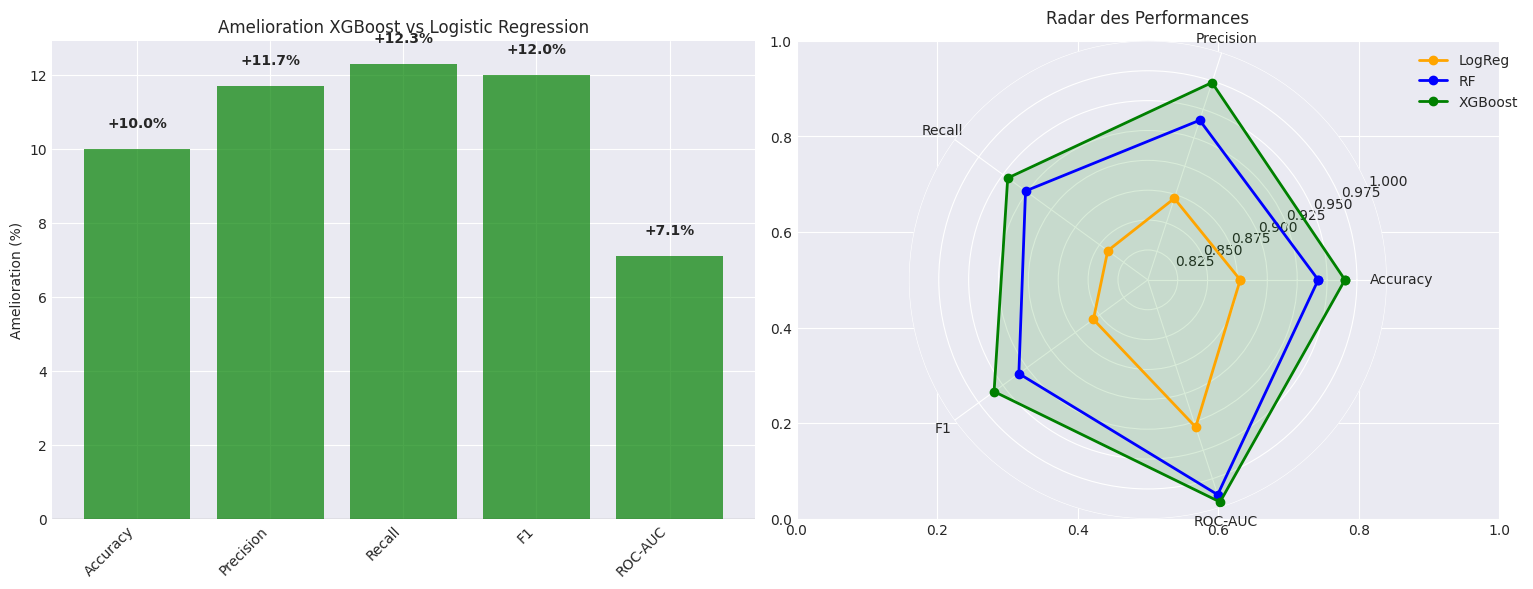

Sauvegarde: /home/esprit/airlLines_Project/results/impact_visualization.png


In [179]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
improvements = [(xgb_metrics[m] - lr_metrics[m]) / lr_metrics[m] * 100 for m in metrics_list]

colors = ['green' if imp > 0 else 'red' for imp in improvements]
axes[0].bar(metrics_list, improvements, color=colors, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_title('Amelioration XGBoost vs Logistic Regression')
axes[0].set_ylabel('Amelioration (%)')
axes[0].set_xticklabels(metrics_list, rotation=45, ha='right')

for i, (metric, imp) in enumerate(zip(metrics_list, improvements)):
    axes[0].text(i, imp + (0.5 if imp > 0 else -0.5), f'{imp:+.1f}%', 
                ha='center', va='bottom' if imp > 0 else 'top', fontweight='bold')

angles = np.linspace(0, 2 * np.pi, len(metrics_list), endpoint=False).tolist()
angles += angles[:1]

lr_values = [lr_metrics[m] for m in metrics_list] + [lr_metrics[metrics_list[0]]]
rf_values = [rf_metrics[m] for m in metrics_list] + [rf_metrics[metrics_list[0]]]
xgb_values = [xgb_metrics[m] for m in metrics_list] + [xgb_metrics[metrics_list[0]]]

axes[1] = plt.subplot(122, projection='polar')
axes[1].plot(angles, lr_values, 'o-', linewidth=2, label='LogReg', color='orange')
axes[1].plot(angles, rf_values, 'o-', linewidth=2, label='RF', color='blue')
axes[1].plot(angles, xgb_values, 'o-', linewidth=2, label='XGBoost', color='green')
axes[1].fill(angles, xgb_values, alpha=0.15, color='green')
axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(metrics_list)
axes[1].set_ylim(0.8, 1.0)
axes[1].set_title('Radar des Performances')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'impact_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sauvegarde: {RESULTS_DIR / 'impact_visualization.png'}")

## 12. Feature Importance (XGBoost)

Top 15 Features Importantes:
                Feature  Importance
        Online Boarding    0.313276
Type of Travel_Personal    0.229233
 In-flight Wifi Service    0.133245
Customer Type_Returning    0.063033
          Class_Economy    0.045436
In-flight Entertainment    0.044517
       Check-in Service    0.018060
           Seat Comfort    0.016992
     Class_Economy Plus    0.015856
       Baggage Handling    0.015102
      In-flight Service    0.014329
       Leg Room Service    0.013323
            Cleanliness    0.012807
          Gate Location    0.011590
       On-board Service    0.011436


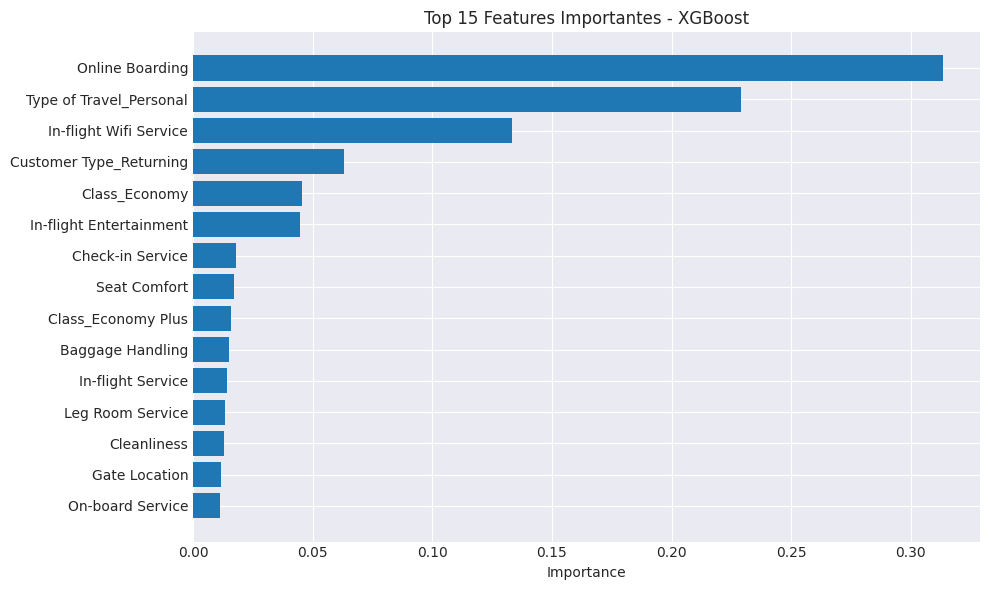

Sauvegarde: /home/esprit/airlLines_Project/results/feature_importance.png


In [180]:
importances = xgb.feature_importances_
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_features = feature_imp.head(15)
print("Top 15 Features Importantes:")
print(top_features.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.title('Top 15 Features Importantes - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sauvegarde: {RESULTS_DIR / 'feature_importance.png'}")

feature_imp.to_csv(RESULTS_DIR / 'feature_importance.csv', index=False)

## 13. Sauvegarde du Meilleur Modele

In [181]:
if xgb_metrics['F1'] > rf_metrics['F1']:
    best_model = xgb
    best_metrics = xgb_metrics
    best_name = 'XGBoost'
else:
    best_model = rf
    best_metrics = rf_metrics
    best_name = 'Random Forest'

model_artifacts = {
    'model': best_model,
    'model_name': best_name,
    'label_encoder': le,
    'scaler': scaler,
    'feature_columns': list(X.columns),
    'categorical_columns': cat_cols,
    'metrics': best_metrics
}

joblib.dump(model_artifacts, RESULTS_DIR / 'satisfaction_model.joblib')
print(f"Modele sauvegarde: {RESULTS_DIR / 'satisfaction_model.joblib'}")
print(f"Meilleur modele: {best_name}")

logger.info(f"Best model: {best_name} with F1={best_metrics['F1']:.4f}")
logger.info("=== SESSION END ===")

2026-05-25 01:24:12,765 - INFO - Best model: XGBoost with F1=0.9591
2026-05-25 01:24:12,767 - INFO - === SESSION END ===


Modele sauvegarde: /home/esprit/airlLines_Project/results/satisfaction_model.joblib
Meilleur modele: XGBoost


## 14. Resume

In [182]:
print("""\n
╔════════════════════════════════════════════════════════════╗
║            CLASSIFICATION ML TERMINEE                      ║
╚════════════════════════════════════════════════════════════╝

Modeles testes:
   • Logistic Regression (baseline)
   • Random Forest
   • XGBoost

Meilleures metriques:
   • Accuracy:  {:.4f}
   • Precision: {:.4f}
   • Recall:    {:.4f}
   • F1-Score:  {:.4f}
   • ROC-AUC:   {:.4f}

Fichiers sauvegardes:
   • model_comparison.csv
   • impact_visualization.png
   • feature_importance.png
   • satisfaction_model.joblib
   • training.log

Prochaine etape:
   • 04_nlp_sentiment.ipynb - NLP sur avis textuels
""".format(
    best_metrics['Accuracy'],
    best_metrics['Precision'],
    best_metrics['Recall'],
    best_metrics['F1'],
    best_metrics['ROC-AUC']
))



╔════════════════════════════════════════════════════════════╗
║            CLASSIFICATION ML TERMINEE                      ║
╚════════════════════════════════════════════════════════════╝

Modeles testes:
   • Logistic Regression (baseline)
   • Random Forest
   • XGBoost

Meilleures metriques:
   • Accuracy:  0.9650
   • Precision: 0.9736
   • Recall:    0.9450
   • F1-Score:  0.9591
   • ROC-AUC:   0.9955

Fichiers sauvegardes:
   • model_comparison.csv
   • impact_visualization.png
   • feature_importance.png
   • satisfaction_model.joblib
   • training.log

Prochaine etape:
   • 04_nlp_sentiment.ipynb - NLP sur avis textuels

